In [5]:
import pandas as pd

# Load the label file without reading image data.
df = pd.read_csv('train.csv')

# Patient ID is the part before the first underscore, e.g. pat_03_image_1.jpg -> pat_03.
df['PatientID'] = df['Name'].str.extract(r'^(pat_\d+)')

# One diagnosis per patient is expected; use the first label and flag any inconsistencies.
patient_diag = (
    df.groupby('PatientID')['Diagnosis']
      .agg(lambda s: s.iloc[0] if s.nunique() == 1 else list(s.unique()))
      .reset_index(name='Diagnosis')
)

num_patients = patient_diag['PatientID'].nunique()
print(f'Unique patients: {num_patients}')
print('\nPatients per diagnosis:')
print(patient_diag['Diagnosis'].value_counts(dropna=False).sort_index())

inconsistent_patients = patient_diag[patient_diag['Diagnosis'].apply(lambda x: isinstance(x, list))]
print(f"\nPatients with inconsistent image labels: {len(inconsistent_patients)}")
if not inconsistent_patients.empty:
    print(inconsistent_patients.head())

# Count how many images belong to each patient.
images_per_patient = df.groupby('PatientID').size().sort_values(ascending=False)

same_count_for_all = images_per_patient.nunique() == 1
print(f'Unique patients: {images_per_patient.shape[0]}')
print(f'Do all patients have the same number of images? {same_count_for_all}')

if same_count_for_all:
    print(f'Images per patient: {int(images_per_patient.iloc[0])}')
else:
    print('\nImages per patient:')
    print(images_per_patient)
    print('\nHow many patients have each image count:')
    print(images_per_patient.value_counts().sort_index())


Unique patients: 12

Patients per diagnosis:
Diagnosis
0    7
1    5
Name: count, dtype: int64

Patients with inconsistent image labels: 0
Unique patients: 12
Do all patients have the same number of images? False

Images per patient:
PatientID
pat_03    10000
pat_07    10000
pat_09    10000
pat_10    10000
pat_11    10000
pat_13    10000
pat_14    10000
pat_15    10000
pat_16    10000
pat_17    10000
pat_18    10000
pat_05     4302
dtype: int64

How many patients have each image count:
4302      1
10000    11
Name: count, dtype: int64


BF image: BF/train/pat_03_image_1006.jpg
FL image: FL/train/pat_03_image_1006.jpg

Original channel information:
BF shape: (128, 128, 3) - Channels: 3
FL shape: (128, 128, 3) - Channels: 3


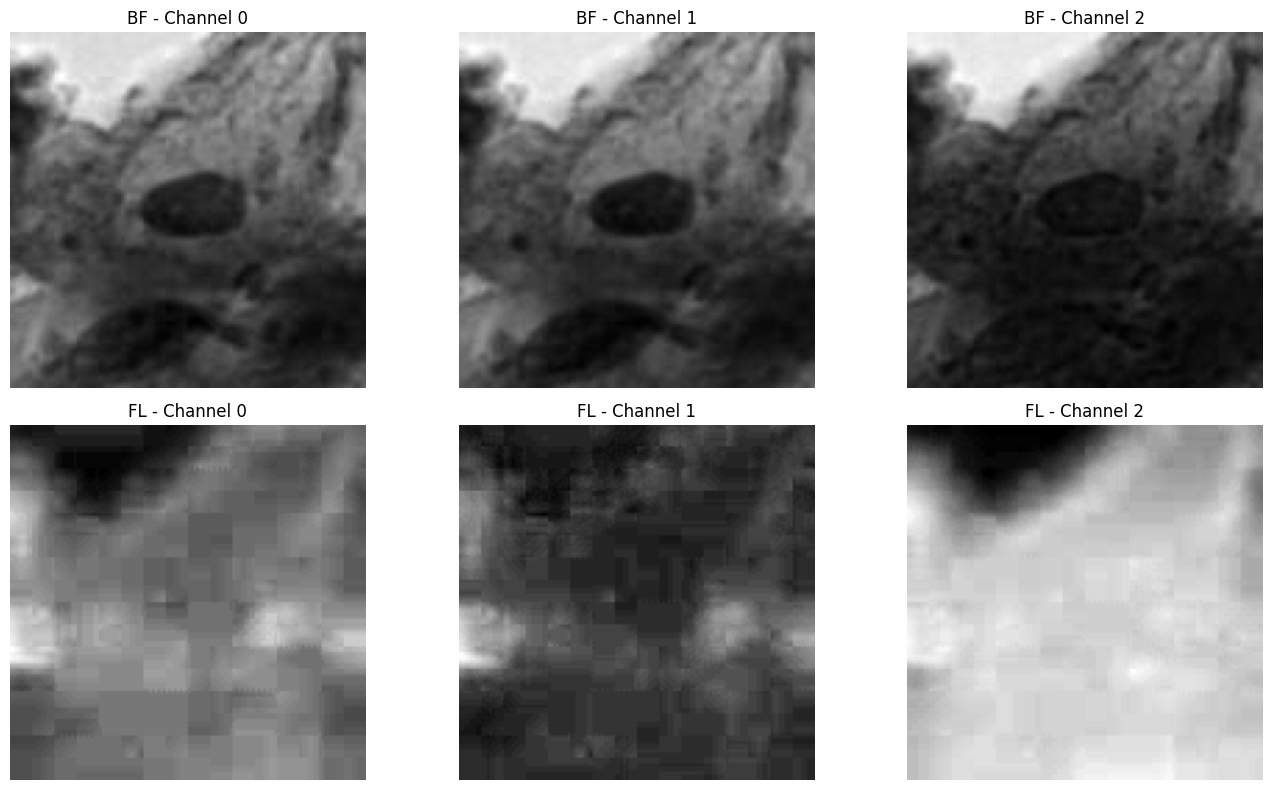

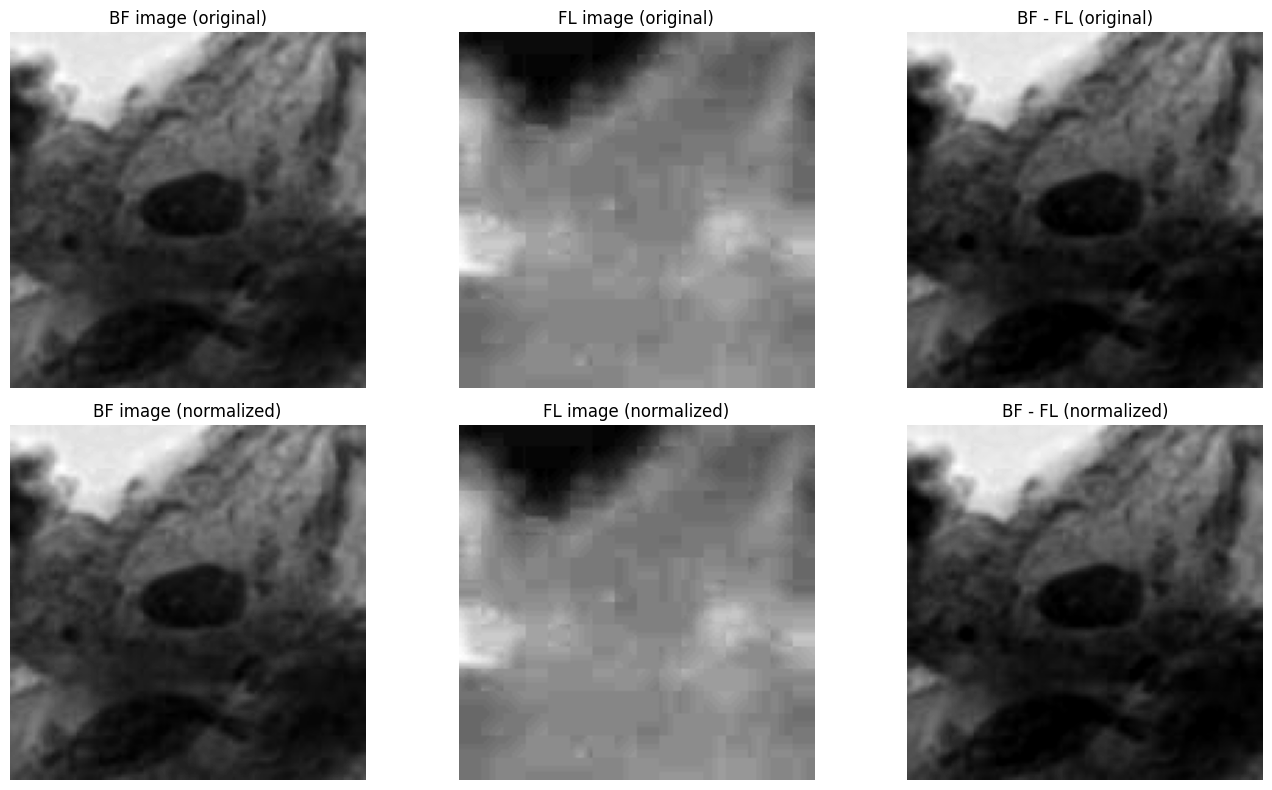

In [6]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def first_image_path(folder: str) -> Path:
    exts = ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff")
    base = Path(folder)
    files = []
    for ext in exts:
        files.extend(base.glob(ext))
    files = sorted(files)
    if not files:
        raise FileNotFoundError(f"No images found in {folder}")
    return files[10]


bf_path = first_image_path("BF/train")
fl_path = first_image_path("FL/train")

# Load in original format to check channels
bf_original = cv2.imread(str(bf_path))
fl_original = cv2.imread(str(fl_path))

print(f"BF image: {bf_path}")
print(f"FL image: {fl_path}")
print(f"\nOriginal channel information:")
print(f"BF shape: {bf_original.shape} - Channels: {bf_original.shape[2] if len(bf_original.shape) == 3 else 1}")
print(f"FL shape: {fl_original.shape} - Channels: {fl_original.shape[2] if len(fl_original.shape) == 3 else 1}")

# Display individual channels
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# BF channels (row 1)
for i in range(3):
    axes[0, i].imshow(bf_original[:, :, i], cmap="gray")
    axes[0, i].set_title(f"BF - Channel {i}")
    axes[0, i].axis("off")

# FL channels (row 2)
for i in range(3):
    axes[1, i].imshow(fl_original[:, :, i], cmap="gray")
    axes[1, i].set_title(f"FL - Channel {i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

# Now load as grayscale for processing
bf = cv2.imread(str(bf_path), cv2.IMREAD_GRAYSCALE)
fl = cv2.imread(str(fl_path), cv2.IMREAD_GRAYSCALE)

if bf is None or fl is None:
    raise ValueError("Could not read one or both images.")

# Ensure both arrays have the same shape before subtraction.
if bf.shape != fl.shape:
    fl = cv2.resize(fl, (bf.shape[1], bf.shape[0]), interpolation=cv2.INTER_AREA)

subtracted = np.clip(bf.astype(np.int16) - fl.astype(np.int16), 0, 255).astype(np.uint8)

# Normalize each image
bf_norm = (bf - bf.min()) / (bf.max() - bf.min() + 1e-6) * 255
fl_norm = (fl - fl.min()) / (fl.max() - fl.min() + 1e-6) * 255
subtracted_norm = (subtracted - subtracted.min()) / (subtracted.max() - subtracted.min() + 1e-6) * 255

plt.figure(figsize=(14, 8))

# Original images
plt.subplot(2, 3, 1)
plt.imshow(bf, cmap="gray")
plt.title("BF image (original)")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(fl, cmap="gray")
plt.title("FL image (original)")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(subtracted, cmap="gray")
plt.title("BF - FL (original)")
plt.axis("off")

# Normalized images
plt.subplot(2, 3, 4)
plt.imshow(bf_norm.astype(np.uint8), cmap="gray")
plt.title("BF image (normalized)")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(fl_norm.astype(np.uint8), cmap="gray")
plt.title("FL image (normalized)")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(subtracted_norm.astype(np.uint8), cmap="gray")
plt.title("BF - FL (normalized)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import densenet121


class CellPairDataset(Dataset):
    def __init__(self, dataframe, bf_root="BF", fl_root="FL", image_size=128):
        self.dataframe = dataframe.reset_index(drop=True)
        self.bf_root = Path(bf_root)
        self.fl_root = Path(fl_root)
        self.image_size = image_size

    def __len__(self):
        return len(self.dataframe)

    def _find_image(self, root: Path, name: str) -> Path:
        matches = list(root.rglob(name))
        if not matches:
            raise FileNotFoundError(f"Could not find {name} under {root}")
        return matches[0]

    def _load_gray(self, path: Path) -> np.ndarray:
        image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not read image at {path}")
        if image.shape != (self.image_size, self.image_size):
            image = cv2.resize(image, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        return image.astype(np.float32)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        name = row["Name"]
        label = float(row["Diagnosis"])

        bf_path = self._find_image(self.bf_root, name)
        fl_path = self._find_image(self.fl_root, name)

        bf = self._load_gray(bf_path)
        fl = self._load_gray(fl_path)
        zeros = np.zeros_like(bf, dtype=np.float32)

        stacked = np.stack([bf, fl, zeros], axis=0) / 255.0
        x = torch.from_numpy(stacked)
        y = torch.tensor([label], dtype=torch.float32)
        return x, y


class DenseNet121BinaryClassifier(nn.Module):
    def __init__(self, checkpoint_path="DenseNet121.pt"):
        super().__init__()
        backbone = densenet121(weights=None)
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 1),
        )
        self.sigmoid = nn.Sigmoid()

        self._load_first_dense_block(checkpoint_path)
        self._freeze_first_dense_block()

    def _load_first_dense_block(self, checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location="cpu")
        model_state = self.state_dict()
        block_state = {
            key.replace("backbone.0.", "features."): value
            for key, value in checkpoint.items()
            if key.startswith("backbone.0.denseblock1.")
        }
        model_state.update(block_state)
        self.load_state_dict(model_state)

    def _freeze_first_dense_block(self):
        for parameter in self.features.denseblock1.parameters():
            parameter.requires_grad = False

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.head(x)
        return self.sigmoid(x)


model = DenseNet121BinaryClassifier("DenseNet121.pt")

trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
frozen_parameters = sum(parameter.numel() for parameter in model.parameters() if not parameter.requires_grad)
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Frozen parameters: {frozen_parameters:,}")
print("First dense block frozen:", all(not parameter.requires_grad for parameter in model.features.denseblock1.parameters()))

# Example forward pass with a 3-channel BF/FL/zero tensor at 128x128.
example_input = torch.randn(2, 3, 128, 128)
example_output = model(example_input)
print("Example output shape:", example_output.shape)

Trainable parameters: 6,750,145
Frozen parameters: 335,040
First dense block frozen: True
Example output shape: torch.Size([2, 1])


Using a random sample of 500 images out of 114302 total rows.

=== BF ===
Magnitude summary (mean absolute channel differences in pixel values):
         mag_rg     mag_rb     mag_gb  mean_magnitude
min    2.755127   7.145142   4.735596        5.513550
25%   20.548386  28.801193  10.975220       23.922028
50%   31.958069  44.301971  15.642059       31.776286
75%   42.947723  56.441772  21.143829       38.912109
mean  32.689642  42.800882  17.138764       30.876429
max   81.124023  74.920715  45.892273       54.292603

Prevalence of effectively identical channels (epsilon=2.0): 0.0000
Spatial coherence summary (lower is more structured/smooth, higher is more noise-like):
      coherence_rg  coherence_rb  coherence_gb  mean_coherence
min       0.014092      0.012496      0.022589        0.031693
25%       0.056846      0.044703      0.093543        0.072942
50%       0.075341      0.062876      0.131045        0.094574
75%       0.108485      0.103914      0.198219        0.131060
mean  

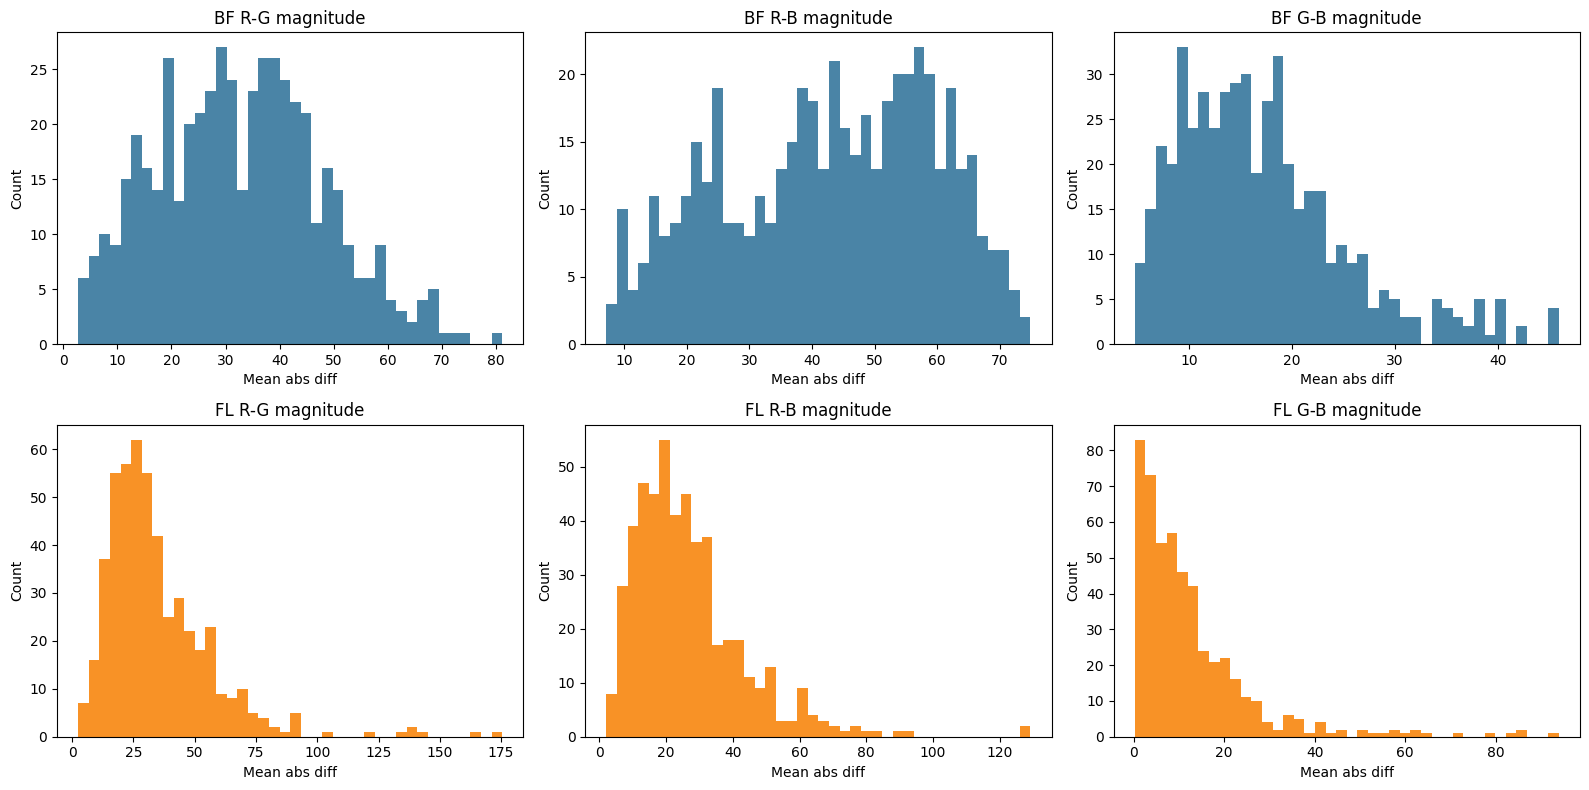

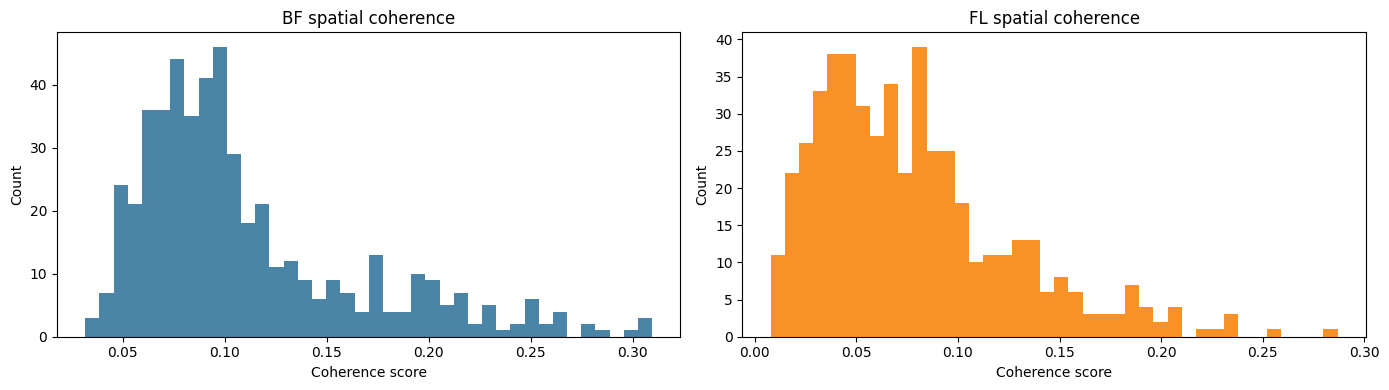

In [4]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Measure per-modality channel structure from a random subset of train.csv.
# For each modality (BF and FL), we compute:
# 1) Magnitude: per-image mean absolute differences between channels.
# 2) Prevalence: fraction of images whose channels are effectively identical.
# 3) Spatial coherence: whether per-pixel differences are structured rather than noise-like.


def first_existing_image(base: Path, name: str) -> Path:
    matches = list(base.rglob(name))
    if not matches:
        raise FileNotFoundError(f"Could not find {name} under {base}")
    return matches[0]


def load_rgb_image(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError(f"Could not read image at {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def channel_difference_metrics(image: np.ndarray, epsilon: float = 2.0) -> dict:
    image_f = image.astype(np.float32)
    r = image_f[:, :, 0]
    g = image_f[:, :, 1]
    b = image_f[:, :, 2]

    rg = r - g
    rb = r - b
    gb = g - b

    mag_rg = float(np.mean(np.abs(rg)))
    mag_rb = float(np.mean(np.abs(rb)))
    mag_gb = float(np.mean(np.abs(gb)))

    identical = (mag_rg < epsilon) and (mag_rb < epsilon) and (mag_gb < epsilon)

    def coherence_score(diff: np.ndarray) -> float:
        dx = np.abs(diff[:, 1:] - diff[:, :-1]).mean()
        dy = np.abs(diff[1:, :] - diff[:-1, :]).mean()
        return float((dx + dy) / (np.mean(np.abs(diff)) + 1e-6))

    coherence_rg = coherence_score(rg)
    coherence_rb = coherence_score(rb)
    coherence_gb = coherence_score(gb)

    return {
        "mag_rg": mag_rg,
        "mag_rb": mag_rb,
        "mag_gb": mag_gb,
        "mean_magnitude": float(np.mean([mag_rg, mag_rb, mag_gb])),
        "identical": identical,
        "coherence_rg": coherence_rg,
        "coherence_rb": coherence_rb,
        "coherence_gb": coherence_gb,
        "mean_coherence": float(np.mean([coherence_rg, coherence_rb, coherence_gb])),
    }


def analyze_modality(modality: str, names: pd.Series, root: str = ".", subset: str = "train", epsilon: float = 2.0) -> pd.DataFrame:
    base = Path(root) / modality / subset
    rows = []
    for name in names:
        path = first_existing_image(base, name)
        image = load_rgb_image(path)
        metrics = channel_difference_metrics(image, epsilon=epsilon)
        metrics["Name"] = name
        metrics["Path"] = str(path)
        rows.append(metrics)
    return pd.DataFrame(rows)


train_df = pd.read_csv("train.csv")

# Randomly sample a manageable subset for quick exploratory analysis.
# Increase sample_size if you want a more stable estimate later.
sample_size = 500
random_state = 42
analysis_df = train_df.sample(n=min(sample_size, len(train_df)), random_state=random_state).reset_index(drop=True)
print(f"Using a random sample of {len(analysis_df)} images out of {len(train_df)} total rows.")

# Run the analysis separately for BF and FL on the same sampled filenames.
bf_stats = analyze_modality("BF", analysis_df["Name"], root=".", subset="train", epsilon=2.0)
fl_stats = analyze_modality("FL", analysis_df["Name"], root=".", subset="train", epsilon=2.0)

for modality_name, stats in [("BF", bf_stats), ("FL", fl_stats)]:
    print(f"\n=== {modality_name} ===")
    print("Magnitude summary (mean absolute channel differences in pixel values):")
    print(stats[["mag_rg", "mag_rb", "mag_gb", "mean_magnitude"]].describe().loc[["min", "25%", "50%", "75%", "mean", "max"]])
    print()
    print(f"Prevalence of effectively identical channels (epsilon=2.0): {stats['identical'].mean():.4f}")
    print("Spatial coherence summary (lower is more structured/smooth, higher is more noise-like):")
    print(stats[["coherence_rg", "coherence_rb", "coherence_gb", "mean_coherence"]].describe().loc[["min", "25%", "50%", "75%", "mean", "max"]])

summary = pd.DataFrame({
    "BF": {
        "mean_magnitude": bf_stats["mean_magnitude"].mean(),
        "identical_fraction": bf_stats["identical"].mean(),
        "mean_coherence": bf_stats["mean_coherence"].mean(),
    },
    "FL": {
        "mean_magnitude": fl_stats["mean_magnitude"].mean(),
        "identical_fraction": fl_stats["identical"].mean(),
        "mean_coherence": fl_stats["mean_coherence"].mean(),
    },
}).T

print("\n=== Modality comparison ===")
print(summary)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
metric_pairs = [
    ("mag_rg", "R-G magnitude"),
    ("mag_rb", "R-B magnitude"),
    ("mag_gb", "G-B magnitude"),
]
for row, stats in enumerate([bf_stats, fl_stats]):
    modality_name = "BF" if row == 0 else "FL"
    for col, (metric, title) in enumerate(metric_pairs):
        axes[row, col].hist(stats[metric], bins=40, color="#2a6f97" if row == 0 else "#f77f00", alpha=0.85)
        axes[row, col].set_title(f"{modality_name} {title}")
        axes[row, col].set_xlabel("Mean abs diff")
        axes[row, col].set_ylabel("Count")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(bf_stats["mean_coherence"], bins=40, color="#2a6f97", alpha=0.85)
axes[0].set_title("BF spatial coherence")
axes[0].set_xlabel("Coherence score")
axes[0].set_ylabel("Count")
axes[1].hist(fl_stats["mean_coherence"], bins=40, color="#f77f00", alpha=0.85)
axes[1].set_title("FL spatial coherence")
axes[1].set_xlabel("Coherence score")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()